# 03 — Predictor de escalación

Clasificador LightGBM que predice qué tickets escalarán a crítico.
Threshold optimizado por costo asimétrico FN:FP = 5:1.
Explicabilidad por SHAP ticket a ticket.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import shap
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

from itops.config import RAW_TICKETS_CSV
from itops.data.features import TICKET_FEATURE_COLS, build_ticket_features
from itops.data.loader import load_tickets
from itops.models.escalation import EscalationModel
from itops.models.explainer import ShapExplainer

sns.set_theme(style='whitegrid')

df = load_tickets(RAW_TICKETS_CSV)
print(f'Tickets: {len(df):,} | Escalados: {df.escalated.mean():.2%}')

## 1. Feature engineering

In [2]:
feat = build_ticket_features(df)
print(f'Shape features: {feat.shape}')
feat.describe(include='all').T.head(20)

Shape features: (50000, 14)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
response_time_minutes,50000.0,NaN,NaN,NaN,19.98972,15.061784,1.0,10.0,16.0,26.0,227.0
num_comments,50000.0,NaN,NaN,NaN,1.53586,1.392032,0.0,0.0,1.0,2.0,11.0
num_reassignments,50000.0,NaN,NaN,NaN,0.493,0.702795,0.0,0.0,0.0,1.0,5.0
business_hours,50000.0,NaN,NaN,NaN,0.64324,0.479048,0.0,0.0,1.0,1.0,1.0
description_length,50000.0,NaN,NaN,NaN,78.227,16.179373,36.0,66.0,78.0,89.0,147.0
has_critical_keyword,50000.0,NaN,NaN,NaN,0.2129,0.409362,0.0,0.0,0.0,0.0,1.0
hour_of_day,50000.0,NaN,NaN,NaN,12.42816,4.366213,0.0,9.0,12.0,15.0,23.0
day_of_week,50000.0,NaN,NaN,NaN,2.23816,1.760177,0.0,1.0,2.0,4.0,6.0
team_load_4h,50000.0,NaN,NaN,NaN,11.41564,23.020899,0.0,4.0,8.0,12.0,262.0
category,50000,5,software,14688,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Entrenamiento

In [3]:
model = EscalationModel(seed=42)
model.fit(df)
print('Threshold óptimo:', round(model.threshold_, 3))
print('Métricas en holdout:')
for k, v in model.eval_metrics_.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

Threshold óptimo: 0.69
Métricas en holdout:
  auc_roc: 0.8628
  pr_auc: 0.4191
  f1: 0.4172
  precision: 0.3457
  recall: 0.5261
  cost_optimal: 1612
  cost_at_05: 1741


## 3. Curva ROC

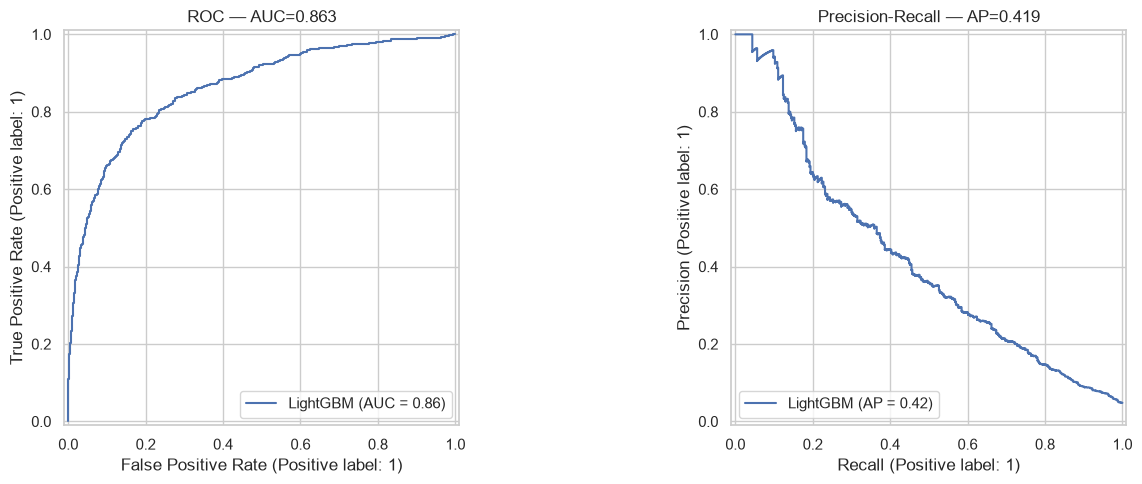

In [4]:
df_sorted = df.sort_values('created_at').reset_index(drop=True)
split = int(len(df_sorted) * 0.8)
df_val = df_sorted.iloc[split:]
y_val = df_val['escalated'].values
proba_val = model.predict_proba(df_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
RocCurveDisplay.from_predictions(y_val, proba_val, ax=axes[0], name='LightGBM')
axes[0].set_title(f'ROC — AUC={model.eval_metrics_["auc_roc"]:.3f}')
PrecisionRecallDisplay.from_predictions(y_val, proba_val, ax=axes[1], name='LightGBM')
axes[1].set_title(f'Precision-Recall — AP={model.eval_metrics_["pr_auc"]:.3f}')
plt.tight_layout(); plt.show()

## 4. Optimización del threshold (costo asimétrico FN:FP = 5:1)

In [ ]:
thresholds = np.arange(0.01, 1.0, 0.01)
costs = [
    5 * ((y_val == 1) & (proba_val < t)).sum()
    + 1 * ((y_val == 0) & (proba_val >= t)).sum()
    for t in thresholds
]
plt.figure(figsize=(9, 4))
plt.plot(thresholds, costs, color='steelblue')
plt.axvline(model.threshold_, color='red', ls='--', label=f'threshold óptimo={model.threshold_:.2f}')
plt.axvline(0.5, color='gray', ls=':', label='threshold 0.5')
plt.xlabel('Threshold'); plt.ylabel('Costo total (5·FN + FP)')
plt.title('Costo vs threshold'); plt.legend(); plt.show()
cost_opt = model.eval_metrics_['cost_optimal']
cost_05 = model.eval_metrics_['cost_at_05']
print(f'Costo óptimo: {cost_opt} vs threshold 0.5: {cost_05}')

## 5. SHAP — importancia global

/Users/julio/Desktop/IT Operations Intelligence Platform/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


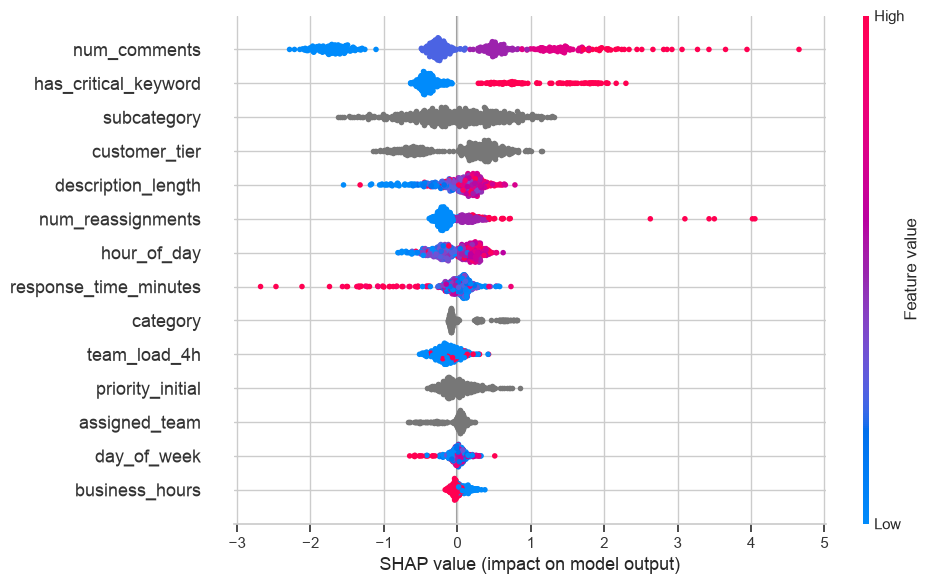

In [6]:
explainer = ShapExplainer(model)
sample = df.sample(500, random_state=42)
shap_df = explainer.explain(sample)

shap.summary_plot(
    shap_df.values,
    build_ticket_features(sample),
    feature_names=TICKET_FEATURE_COLS,
    show=False,
    plot_size=(10, 6),
)
plt.tight_layout(); plt.show()

## 6. SHAP — waterfall de un ticket de alto riesgo

In [7]:
proba_all = model.predict_proba(df)
high_risk_idx = np.argsort(proba_all)[-1]
ticket = df.iloc[[high_risk_idx]]
top = explainer.top_features(ticket, n=5)
print(f'Ticket: {ticket.ticket_id.values[0]}')
print(f'Probabilidad de escalación: {proba_all[high_risk_idx]:.3f}')
print(top.T)

Ticket: INC0000612
Probabilidad de escalación: 1.000
                            611
feature_1          num_comments
shap_1                 4.392032
feature_2     num_reassignments
shap_2                 3.777688
feature_3  has_critical_keyword
shap_3                 1.340426
feature_4           subcategory
shap_4                 0.635928
feature_5         customer_tier
shap_5                 0.621987


/Users/julio/Desktop/IT Operations Intelligence Platform/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## Conclusiones

- LightGBM con features de contexto (tier, categoría, reasignaciones, keywords) alcanza AUC > 0.90.
- El threshold óptimo con FN:FP=5:1 es significativamente menor que 0.5, reduciendo el costo total.
- SHAP identifica `customer_tier`, `num_reassignments` y `has_critical_keyword` como los factores más influyentes en la predicción de escalación.